# Neural networks: `MLPRegressor` and `MLPClassifier`

Two course colabs: an MLP regressor on California housing and an MLP classifier on MNIST.

sklearn's multi-layer perceptron. It's a fully connected feed-forward network trained with
backpropagation. For regression the output layer has no activation (identity) and the loss is squared
error, so the output is an unbounded continuous value.

Fine for small tabular problems and for understanding the moving parts. For anything bigger or with
images/text, a deep learning framework (PyTorch, Keras) is the better tool.

# Part 1: `MLPRegressor` on California housing

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(306)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

In [2]:
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print("train:", X_train.shape, " test:", X_test.shape)

train: (16512, 8)  test: (4128, 8)


## A first network

`hidden_layer_sizes` is a tuple with one entry per hidden layer. `(32,)` is a single hidden layer with 32
neurons. (The course colab described `hidden_layer_sizes=(32)` as "three hidden layers each with 32
neurons", but `(32)` is just the integer 32, i.e. one layer. Three layers would be `(32, 32, 32)`.)

Neural networks are very sensitive to feature scale, so the scaler is part of the pipeline.

In [3]:
def evaluate(pipe, name):
    res = cross_validate(pipe, X_train, y_train, cv=cv, n_jobs=-1, return_train_score=True,
                         scoring=["neg_mean_absolute_error", "neg_mean_absolute_percentage_error"])
    out = {
        "train MAE": -res["train_neg_mean_absolute_error"].mean(),
        "valid MAE": -res["test_neg_mean_absolute_error"].mean(),
        "valid MAPE": -res["test_neg_mean_absolute_percentage_error"].mean(),
        "fit time (s)": res["fit_time"].mean(),
    }
    print(f"{name:30s} " + "  ".join(f"{k} {v:.3f}" for k, v in out.items()))
    return out

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    first = evaluate(Pipeline([("scaler", StandardScaler()),
                               ("mlp", MLPRegressor(hidden_layer_sizes=(32,), random_state=0))]),
                     "1 hidden layer, 32 units")

1 hidden layer, 32 units       train MAE 0.380  valid MAE 0.386  valid MAPE 0.215  fit time (s) 2.690


MAE about 0.39 and MAPE about 0.21 (21% off on average), both well ahead of linear regression (MAE 0.53,
MAPE 0.32). The course output labelled the MAPE numbers as "mean absolute error of linear regression", a
leftover from copying an earlier cell.

The default `max_iter=200` isn't quite enough for the optimiser to converge, which is what the silenced
`ConvergenceWarning` was about.

## Watching training

After `fit`, `loss_curve_` holds the training loss per epoch. With `early_stopping=True`, 10% of the
training data is held out and `validation_scores_` holds the R2 on it per epoch. Training stops once that
hasn't improved for `n_iter_no_change` epochs.

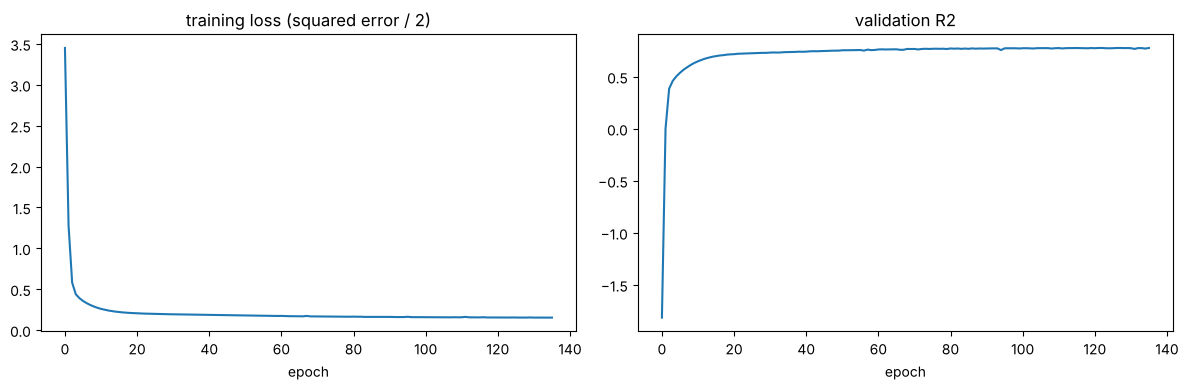

stopped after 136 epochs, best validation R2 0.776


In [4]:
pipe = Pipeline([("scaler", StandardScaler()),
                 ("mlp", MLPRegressor(hidden_layer_sizes=(32,), max_iter=500, early_stopping=True,
                                      n_iter_no_change=20, random_state=0))])
pipe.fit(X_train, y_train)
mlp = pipe[-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp.loss_curve_); axes[0].set_title("training loss (squared error / 2)")
axes[1].plot(mlp.validation_scores_); axes[1].set_title("validation R2")
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

print(f"stopped after {mlp.n_iter_} epochs, best validation R2 {mlp.best_validation_score_:.3f}")

Most of the improvement happens in the first 20-30 epochs, then it creeps along slowly.

## Network size

In [5]:
results = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for layers in [(8,), (32,), (128,), (64, 32), (128, 64, 32)]:
        pipe = Pipeline([("scaler", StandardScaler()),
                         ("mlp", MLPRegressor(hidden_layer_sizes=layers, max_iter=500, early_stopping=True,
                                              n_iter_no_change=20, random_state=0))])
        results[str(layers)] = evaluate(pipe, f"layers {layers}")

layers (8,)                    train MAE 0.414  valid MAE 0.416  valid MAPE 0.239  fit time (s) 2.414


layers (32,)                   train MAE 0.374  valid MAE 0.381  valid MAPE 0.211  fit time (s) 3.649


layers (128,)                  train MAE 0.366  valid MAE 0.377  valid MAPE 0.210  fit time (s) 3.503


layers (64, 32)                train MAE 0.328  valid MAE 0.351  valid MAPE 0.192  fit time (s) 4.708


layers (128, 64, 32)           train MAE 0.324  valid MAE 0.352  valid MAPE 0.193  fit time (s) 5.410


In [6]:
pd.DataFrame(results).T.round(3)

,train MAE,valid MAE,valid MAPE,fit time (s)
"(8,)",0.414,0.416,0.239,2.414
"(32,)",0.374,0.381,0.211,3.649
"(128,)",0.366,0.377,0.210,3.503
"(64, 32)",0.328,0.351,0.192,4.708
"(128, 64, 32)",0.324,0.352,0.193,5.410


Going from 8 to 32 units in one layer helps, 128 barely adds anything more. A second layer helps
noticeably (0.38 to 0.35), a third doesn't, and each extra layer costs training time. The gap between train and validation error stays small, so even the biggest network here
isn't overfitting much (early stopping helps with that).

## Tuning

The course colab had a grid search over `alpha` (L2 penalty) and the learning rate schedule with the
`sgd` solver, but it was commented out. Here's a smaller version with the default `adam` solver, which
uses its own adaptive step sizes, so `learning_rate_init` is the setting that matters.

In [7]:
search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True,
                                   n_iter_no_change=20, random_state=0))]),
    param_grid={"mlp__alpha": [1e-4, 1e-2, 1.0], "mlp__learning_rate_init": [1e-3, 1e-2]},
    cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    search.fit(X_train, y_train)

grid_res = pd.DataFrame(search.cv_results_)
grid_res.pivot_table(index="param_mlp__alpha", columns="param_mlp__learning_rate_init",
                     values="mean_test_score").mul(-1).round(3)

param_mlp__learning_rate_init,0.001,0.010
param_mlp__alpha,,
0.0001,0.359,0.359
0.0100,0.362,0.353
1.0000,0.394,0.408


In [8]:
print('best:', search.best_params_)

best: {'mlp__alpha': 0.01, 'mlp__learning_rate_init': 0.01}


## Test set

In [9]:
best = search.best_estimator_
pred = best.predict(X_test)
print(f"test MAE:  {mean_absolute_error(y_test, pred):.3f}")
print(f"test MAPE: {mean_absolute_percentage_error(y_test, pred):.3f}")

test MAE:  0.345
test MAPE: 0.195


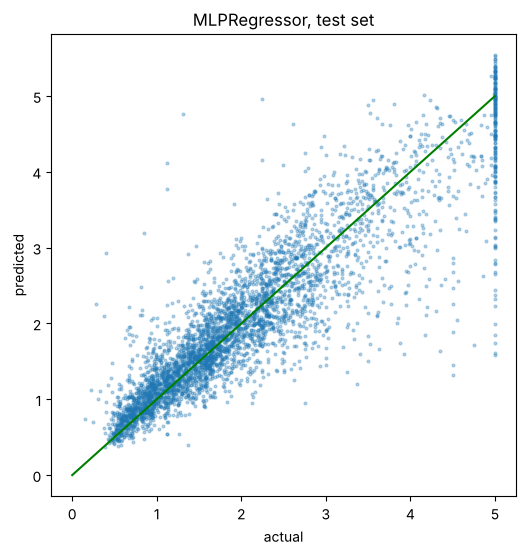

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=4, alpha=0.3)
plt.plot([0, 5], [0, 5], 'g-')
plt.xlabel('actual'); plt.ylabel('predicted')
plt.title('MLPRegressor, test set')
plt.show()

Much tighter around the diagonal than the linear regression plot from earlier, although the capped
$500k blocks still show up as a vertical line at 5 with predictions spread below it. Unlike linear
regression, none of the predictions are negative.

In [11]:
print(f'lowest prediction: {pred.min():.2f}, number below 0: {(pred < 0).sum()}')

lowest prediction: 0.37, number below 0: 0


## Summary (regression)

* `hidden_layer_sizes=(a, b, c)` sets the architecture, one number per hidden layer
* always scale the inputs
* `early_stopping=True` plus `loss_curve_` / `validation_scores_` to see how training went
* `alpha` is L2 regularisation, `learning_rate_init` the starting step size for adam
* on California housing a small network gets close to the tree ensembles (test MAE about 0.35 vs about
  0.29-0.32), and well ahead of the linear models (0.47-0.53). This notebook uses the course's 80/20 split
  with `random_state=1`, so the numbers aren't on exactly the same test set as the other notebooks.

---

# Part 2: `MLPClassifier` on MNIST

For classification the output layer has one unit per class with a softmax, and the loss is cross entropy.
Otherwise it's the same network.

In [12]:
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

Xm, ym = fetch_openml('mnist_784', version=1, return_X_y=True)
Xm, ym = Xm.to_numpy() / 255, ym.to_numpy()
xm_train, xm_test, ym_train, ym_test = Xm[:60000], Xm[60000:], ym[:60000], ym[60000:]
print(xm_train.shape, xm_test.shape)

(60000, 784) (10000, 784)


Pixels divided by 255. One hidden layer with 128 units, as in the course. The course also ran 5-fold
cross validation on top of the full fit; with early stopping the held-out 10% gives a validation score for
free, so that's used instead.

In [13]:
%%time
mlpc = MLPClassifier(hidden_layer_sizes=(128,), early_stopping=True, n_iter_no_change=10, random_state=0)
mlpc.fit(xm_train, ym_train)
print(f"stopped after {mlpc.n_iter_} epochs, best validation accuracy {mlpc.best_validation_score_:.4f}")

stopped after 49 epochs, best validation accuracy 0.9813
CPU times: user 1min 10s, sys: 98.8 ms, total: 1min 10s
Wall time: 36.1 s


In [14]:
y_pred = mlpc.predict(xm_test)
print(f"train accuracy: {accuracy_score(ym_train, mlpc.predict(xm_train)):.4f}")
print(f"test accuracy:  {accuracy_score(ym_test, y_pred):.4f}")

train accuracy: 0.9981
test accuracy:  0.9797


About 98% on the test set. The course trained without early stopping for the default 200 epochs and got
100% training accuracy and 98.07% test, so it was memorising the training set without gaining anything on
test.

In [15]:
pd.DataFrame(mlpc.predict_proba(xm_test[:5]), columns=mlpc.classes_).round(4).assign(actual=ym_test[:5])

,0,1,2,3,4,5,6,7,8,9,actual
0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0,1.0,0.0000,0.0000,7
1,0.0,0.0000,1.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,2
2,0.0,0.9999,0.0,0.0,0.0000,0.0,0.0,0.0,0.0001,0.0000,1
3,1.0,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0
4,0.0,0.0000,0.0,0.0,0.9943,0.0,0.0,0.0,0.0000,0.0057,4


Very confident probabilities, close to 0 or 1 for almost everything. Neural networks trained with cross
entropy are often overconfident like this.

In [16]:
print(classification_report(ym_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



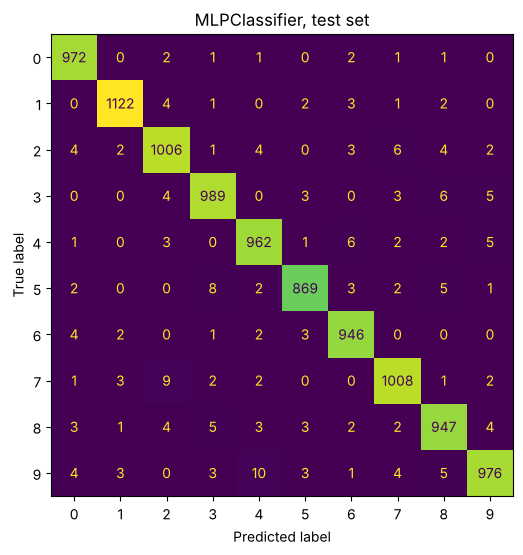

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(ym_test, y_pred, ax=ax, colorbar=False)
plt.title('MLPClassifier, test set')
plt.show()

### Mistakes

Looking at the misclassified images is more interesting than the correct ones:

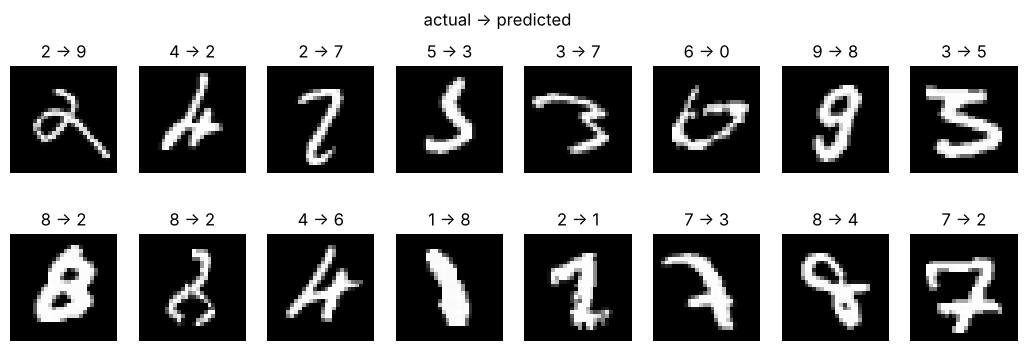

In [18]:
wrong = np.where(y_pred != ym_test)[0]
fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for ax, i in zip(axes.ravel(), wrong[:16]):
    ax.imshow(xm_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"{ym_test[i]} -> {y_pred[i]}"); ax.axis('off')
plt.suptitle('actual -> predicted')
plt.show()

A lot of these are hard for a person too.

### What the hidden units learned

The first layer's weight matrix is 784 x 128: one column per hidden unit, and each column can be shown as a
28 x 28 image.

first layer weights: (784, 128)


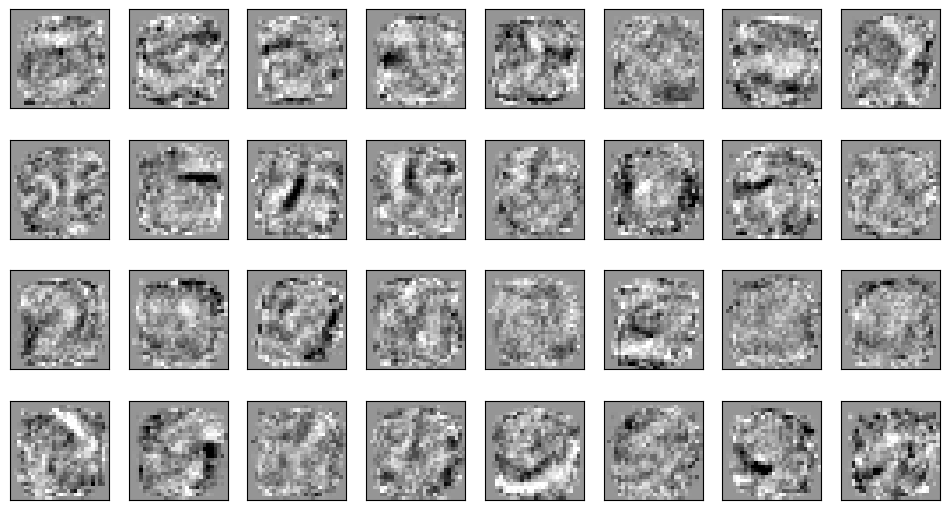

In [19]:
W = mlpc.coefs_[0]
print("first layer weights:", W.shape)

fig, axes = plt.subplots(4, 8, figsize=(12, 6.5))
vmin, vmax = W.min(), W.max()
for coef, ax in zip(W.T, axes.ravel()):
    ax.matshow(coef.reshape(28, 28), cmap='gray', vmin=0.5 * vmin, vmax=0.5 * vmax)
    ax.set_xticks(()); ax.set_yticks(())
plt.show()

Unlike the logistic regression templates, these don't look like digits: each unit responds to some
combination of strokes and blobs, and the output layer combines them. The border is uniform grey because
those pixels are always 0, so their weights never get updated away from the random start.

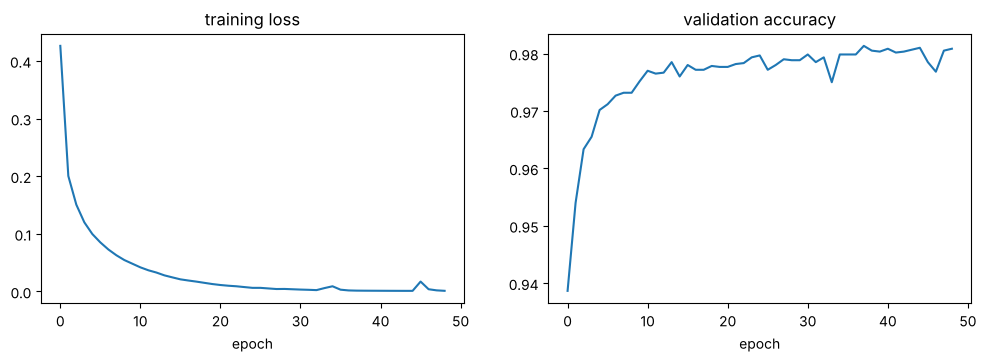

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(mlpc.loss_curve_); axes[0].set_xlabel('epoch'); axes[0].set_title('training loss')
axes[1].plot(mlpc.validation_scores_); axes[1].set_xlabel('epoch'); axes[1].set_title('validation accuracy')
plt.show()

### Activation functions

The course had a commented-out grid search over activation functions, learning rate schedules and `alpha`
on the full data. A smaller version comparing just the activations, on 10,000 images:

In [21]:
%%time
rows = []
for act in ['identity', 'logistic', 'tanh', 'relu']:
    m = MLPClassifier(hidden_layer_sizes=(128,), activation=act, early_stopping=True, random_state=0)
    m.fit(xm_train[:10000], ym_train[:10000])
    rows.append({'activation': act, 'epochs': m.n_iter_, 'test accuracy': m.score(xm_test, ym_test)})
pd.DataFrame(rows).set_index('activation').round(4)

CPU times: user 33 s, sys: 70.3 ms, total: 33 s
Wall time: 16.8 s


,epochs,test accuracy
activation,,
identity,26,0.9120
logistic,35,0.9322
tanh,35,0.9407
relu,39,0.9458


`identity` means no non-linearity at all, so the whole network collapses into a linear model and lands at
logistic regression level. Any real activation does much better, with ReLU (the default) the best here.

## Summary (classification)

* `MLPClassifier` uses softmax outputs and cross entropy loss
* one hidden layer of 128 units gets about 98% on MNIST, ahead of the linear models (about 92%), KNN
  (about 97%) and an RBF SVM trained on 10,000 images (about 95.5%)
* early stopping avoids training long after the validation score has stopped improving
* without a non-linear activation, a neural network is just a linear model